# 05 — PMI Word Associations

This notebook uses Pointwise Mutual Information (PMI) to identify word associations.

Where TF-IDF asks "which lexemes are distinctive for a genre?", PMI asks "which lexemes tend to appear near each other?"

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis")
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_DIR / "output"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
DOCS_DIR = PROJECT_DIR / "docs"
POSTER_DIR = PROJECT_DIR / "poster"

for folder in [PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, DOCS_DIR, POSTER_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.chdir(NOTEBOOK_DIR)
print("Project directory:", PROJECT_DIR)
print("Current folder:", os.getcwd())


!pip -q install pandas matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from itertools import combinations
import math

Mounted at /content/drive
Project directory: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis
Current folder: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/notebooks


## 2. Load content tokens

In [2]:
content = pd.read_csv(PROCESSED_DIR / "biblical_hebrew_content_tokens.csv")
content["lex_clean"] = content["lex_clean"].astype(str).str.strip()

# Sort tokens by textual order to preserve local context.
content = content.sort_values(["book", "chapter", "verse", "word_node"]).reset_index(drop=True)

print("Content tokens:", len(content))
print(content.groupby("genre").size())

content.head()

Content tokens: 14707
genre
Law              2971
Narrative        4057
Poetry_Wisdom    3978
Prophecy         3701
dtype: int64


,book,chapter,verse,genre,word_node,word,lex,pos,word_utf8,gloss,lex_clean
0,Amos,1,1,Prophecy,295386,דִּבְרֵ֣י,DBR/,subs,דִּבְרֵ֣י,word,DBR/
1,Amos,1,1,Prophecy,295389,הָיָ֥ה,HJH[,verb,הָיָ֥ה,be,HJH[
2,Amos,1,1,Prophecy,295392,נֹּקְדִ֖ים,NQD/,subs,נֹּקְדִ֖ים,sheep-raiser,NQD/
3,Amos,1,1,Prophecy,295396,חָזָ֨ה,XZH[,verb,חָזָ֨ה,see,XZH[
4,Amos,1,1,Prophecy,295400,ימֵ֣י׀,JWM/,subs,ימֵ֣י,day,JWM/


## 3. Build co-occurrence counts

PMI is calculated within genre. Two lexemes are treated as co-occurring if they appear in the same verse. This is a transparent choice for a pilot project because verses are meaningful textual units and easier to explain than arbitrary window sizes.

In [3]:
MIN_WORD_COUNT = 5
MIN_PAIR_COUNT = 2

all_pmi_rows = []

for genre, genre_df in content.groupby("genre"):
    verse_groups = genre_df.groupby(["book", "chapter", "verse"])["lex_clean"].apply(list)

    word_counts = Counter()
    pair_counts = Counter()
    total_windows = 0

    for words in verse_groups:
        # Use unique lexemes per verse so repeated words do not dominate co-occurrence.
        unique_words = sorted(set(w for w in words if isinstance(w, str) and w.strip()))
        if len(unique_words) < 2:
            continue

        total_windows += 1
        word_counts.update(unique_words)
        pair_counts.update(combinations(unique_words, 2))

    for (w1, w2), pair_count in pair_counts.items():
        if pair_count < MIN_PAIR_COUNT:
            continue
        if word_counts[w1] < MIN_WORD_COUNT or word_counts[w2] < MIN_WORD_COUNT:
            continue

        p_pair = pair_count / total_windows
        p_w1 = word_counts[w1] / total_windows
        p_w2 = word_counts[w2] / total_windows

        pmi = math.log2(p_pair / (p_w1 * p_w2))

        all_pmi_rows.append({
            "genre": genre,
            "word1": w1,
            "word2": w2,
            "pair_count": pair_count,
            "word1_count": word_counts[w1],
            "word2_count": word_counts[w2],
            "pmi": pmi,
        })

pmi_df = pd.DataFrame(all_pmi_rows).sort_values(["genre", "pmi"], ascending=[True, False])
pmi_df.to_csv(TABLES_DIR / "pmi_word_associations.csv", index=False)

top_pmi_by_genre = pmi_df.groupby("genre").head(25).reset_index(drop=True)
top_pmi_by_genre.to_csv(TABLES_DIR / "top_pmi_by_genre.csv", index=False)

top_pmi_by_genre.head(50)

,genre,word1,word2,pair_count,word1_count,word2_count,pmi
0,Law,JTRT/,KBD=/,5,5,5,5.887525
1,Law,JTRT/,KLJH/,5,5,5,5.887525
2,Law,JTRT/,KSL=/,5,5,5,5.887525
3,Law,KBD=/,KLJH/,5,5,5,5.887525
4,Law,KBD=/,KSL=/,5,5,5,5.887525
5,Law,KLJH/,KSL=/,5,5,5,5.887525
6,Law,JSWD/,QRN/,5,6,5,5.624491
7,Law,>MH/,FMX[,4,5,6,5.302563
8,Law,CNJM/,JTRT/,5,8,5,5.209453
9,Law,CNJM/,KBD=/,5,8,5,5.209453


## 4. PMI summary by genre

In [4]:
summary = (
    top_pmi_by_genre
    .assign(pair=lambda df: df["word1"] + " — " + df["word2"])
    .groupby("genre")["pair"]
    .apply(lambda pairs: "; ".join(list(pairs)[:10]))
    .reset_index(name="top_pmi_pairs")
)

summary.to_csv(TABLES_DIR / "pmi_summary_by_genre.csv", index=False)
summary

,genre,top_pmi_pairs
0,Law,JTRT/ — KBD=/; JTRT/ — KLJH/; JTRT/ — KSL=/; K...
1,Narrative,NB>[ — NBJ>/; <ZB[ — XWY/; BFR/ — PRH/; BGD/ —...
2,Poetry_Wisdom,NKRJ/ — ZR/; CKB[ — CNH=/; >B/ — >M/; C<R/ — P...
3,Prophecy,CJT/ — CMJR/; >WR/ — XCK/; CBV/ — MVH/; R</ — ...


## 5. Visualize top PMI pairs

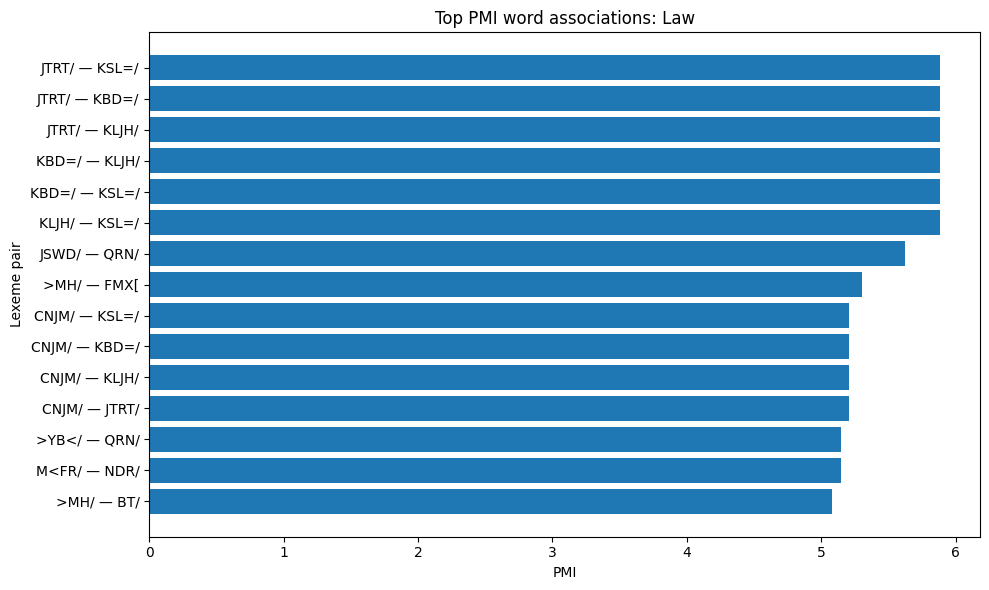

Saved: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/output/figures/top_pmi_Law.png


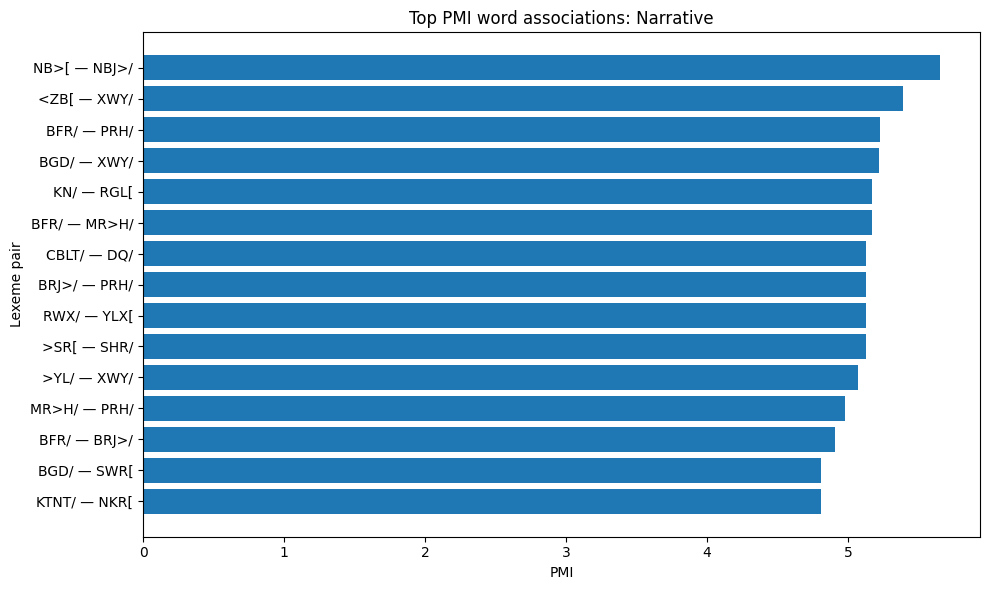

Saved: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/output/figures/top_pmi_Narrative.png


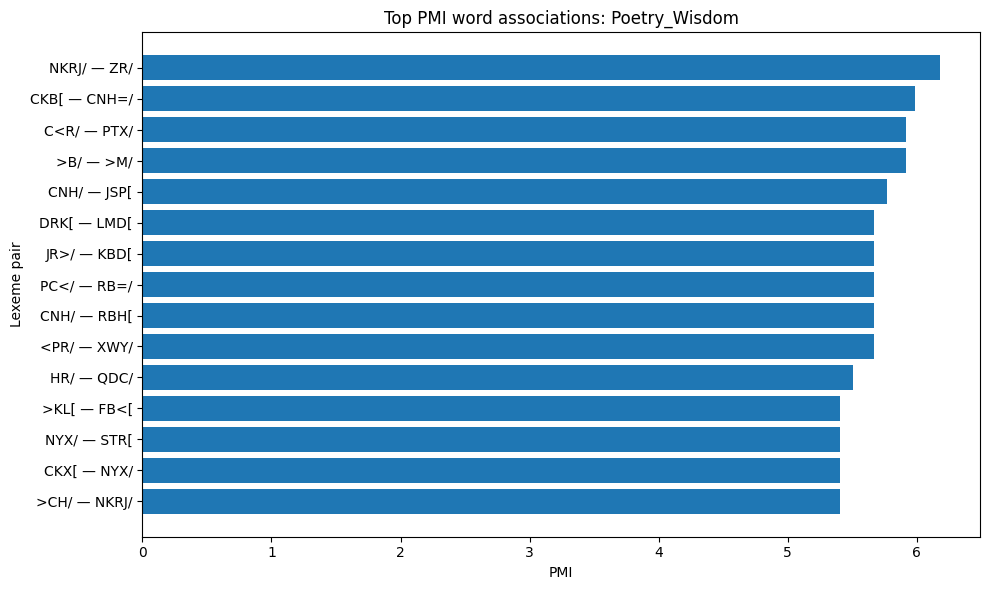

Saved: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/output/figures/top_pmi_Poetry_Wisdom.png


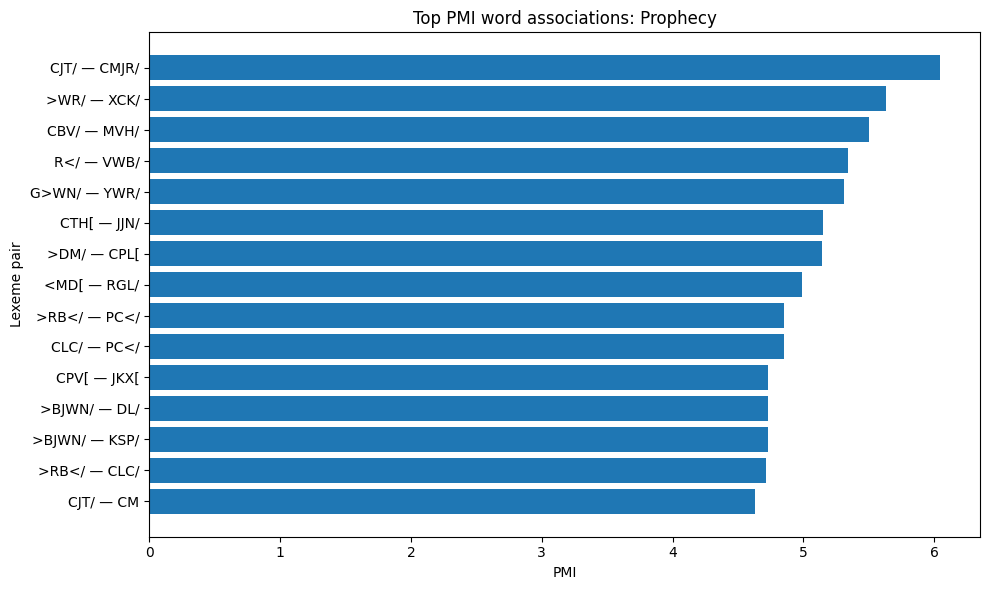

Saved: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/output/figures/top_pmi_Prophecy.png


In [5]:
for genre, group in top_pmi_by_genre.groupby("genre"):
    plot_data = group.head(15).copy()
    plot_data["pair"] = plot_data["word1"] + " — " + plot_data["word2"]
    plot_data = plot_data.sort_values("pmi", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_data["pair"], plot_data["pmi"])
    plt.xlabel("PMI")
    plt.ylabel("Lexeme pair")
    plt.title(f"Top PMI word associations: {genre}")
    plt.tight_layout()

    filename = FIGURES_DIR / f"top_pmi_{genre}.png"
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", filename)

## 6. Interpretation checkpoint

PMI should be interpreted carefully. It highlights unusually strong associations, not necessarily the most important words overall. Minimum count thresholds are used to reduce noise from rare pairs.